#Libraries

In [ ]:
import pandas as pd
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

from sklearn.preprocessing import StandardScaler
import pickle

#PHASE 1 - DATASET MERGING

## LOAD ALL DATASETS

In [ ]:
base_path = "/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/raw data/"

In [ ]:
orders = pd.read_csv(base_path + 'olist_orders_dataset.csv')
order_items = pd.read_csv(base_path + 'olist_order_items_dataset.csv')
order_payments = pd.read_csv(base_path + 'olist_order_payments_dataset.csv')
order_reviews = pd.read_csv(base_path + 'olist_order_reviews_dataset.csv')
customers = pd.read_csv(base_path + 'olist_customers_dataset.csv')
products = pd.read_csv(base_path + 'olist_products_dataset.csv')
sellers = pd.read_csv(base_path + 'olist_sellers_dataset.csv')
category_translation = pd.read_csv(base_path + 'product_category_name_translation.csv')


datasets = {
    "orders": orders,
    "order_items": order_items,
    "order_payments": order_payments,
    "order_reviews": order_reviews,
    "customers": customers,
    "products": products,
    "sellers": sellers
}

print("Datasets loaded successfully")

Datasets loaded successfully


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


##Check Shape

In [ ]:
print(f"Orders: {orders.shape}")
print(f"Order Items: {order_items.shape}")
print(f"Order Payments: {order_payments.shape}")
print(f"Order Reviews: {order_reviews.shape}")
print(f"Customers: {customers.shape}")
print(f"Products: {products.shape}")
print(f"Sellers: {sellers.shape}")

Orders: (99441, 8)
Order Items: (112650, 7)
Order Payments: (103886, 5)
Order Reviews: (99224, 7)
Customers: (99441, 5)
Products: (32951, 9)
Sellers: (3095, 4)


##Check Columns

In [ ]:
orders.columns.tolist()

['order_id',
 'customer_id',
 'order_status',
 'order_purchase_timestamp',
 'order_approved_at',
 'order_delivered_carrier_date',
 'order_delivered_customer_date',
 'order_estimated_delivery_date']

In [ ]:
customers.columns.tolist()

['customer_id',
 'customer_unique_id',
 'customer_zip_code_prefix',
 'customer_city',
 'customer_state']

In [ ]:
products.columns.tolist()

['product_id',
 'product_category_name',
 'product_name_lenght',
 'product_description_lenght',
 'product_photos_qty',
 'product_weight_g',
 'product_length_cm',
 'product_height_cm',
 'product_width_cm']

In [ ]:
order_items.columns.tolist()

['order_id',
 'order_item_id',
 'product_id',
 'seller_id',
 'shipping_limit_date',
 'price',
 'freight_value']

In [ ]:
order_payments.columns.tolist()

['order_id',
 'payment_sequential',
 'payment_type',
 'payment_installments',
 'payment_value']

In [ ]:
order_reviews.columns.tolist()

['review_id',
 'order_id',
 'review_score',
 'review_comment_title',
 'review_comment_message',
 'review_creation_date',
 'review_answer_timestamp']

In [ ]:
sellers.columns.tolist()

['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

##Check Sample Records

In [ ]:
orders.head(3)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00


In [ ]:
customers.head(3)

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP


In [ ]:
products.head(3)

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0


In [ ]:
sellers.head(3)

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ


In [ ]:
order_reviews.head(3)

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24


In [ ]:
order_items.head(3)

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.9,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.9,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.0,17.87


In [ ]:
order_payments.head(3)

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71


##Check Duplicates

In [ ]:
orders['order_id'].nunique(), len(orders)

(99441, 99441)

In [ ]:
customers['customer_id'].nunique(), len(customers)

(99441, 99441)

In [ ]:
order_items['order_id'].nunique(), len(order_items)

(98666, 112650)

In [ ]:
order_payments['order_id'].nunique(), len(order_payments)

(99440, 103886)

In [ ]:
order_reviews['order_id'].nunique(), len(order_reviews)

(98673, 99224)

##Check Missing Values

In [ ]:
for name, df in datasets.items():
    print("\n", name)
    print(df.isnull().sum().sort_values(ascending=False).head())


 orders
order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
order_id                            0
order_purchase_timestamp            0
dtype: int64

 order_items
order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
dtype: int64

 order_payments
order_id                0
payment_sequential      0
payment_type            0
payment_installments    0
payment_value           0
dtype: int64

 order_reviews
review_comment_title      87656
review_comment_message    58247
review_id                     0
review_score                  0
order_id                      0
dtype: int64

 customers
customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

 products
product_category_name         610
product_description_lenght    610
product_name_lenght           610

##PRE-MERGE AGGREGATIONS

In [ ]:
# Aggregate order_items — one row per order

items_agg = order_items.groupby('order_id').agg(
    total_items   = ('order_item_id', 'count'),
    total_price   = ('price',         'sum'),
    total_freight = ('freight_value', 'sum'),
    seller_id     = ('seller_id',     'first'),
    product_id    = ('product_id',    'first')
).reset_index()

In [ ]:
items_agg.shape


(98666, 6)

In [ ]:
items_agg.head()

,order_id,total_items,total_price,total_freight,seller_id,product_id
0,00010242fe8c5a6d1ba2dd792cb16214,1,58.90,13.29,48436dade18ac8b2bce089ec2a041202,4244733e06e7ecb4970a6e2683c13e61
1,00018f77f2f0320c557190d7a144bdd3,1,239.90,19.93,dd7ddc04e1b6c2c614352b383efe2d36,e5f2d52b802189ee658865ca93d83a8f
2,000229ec398224ef6ca0657da4fc703e,1,199.00,17.87,5b51032eddd242adc84c38acab88f23d,c777355d18b72b67abbeef9df44fd0fd
3,00024acbcdf0a6daa1e931b038114c75,1,12.99,12.79,9d7a1d34a5052409006425275ba1c2b4,7634da152a4610f1595efa32f14722fc
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,199.90,18.14,df560393f3a51e74553ab94004ba5c87,ac6c3623068f30de03045865e4e10089


In [ ]:
# Aggregate payments — one row per order

payments_agg = order_payments.groupby('order_id').agg(
    total_payment_value  = ('payment_value',        'sum'),
    payment_installments = ('payment_installments', 'max'),
    payment_type         = ('payment_type',         'first')
).reset_index()

In [ ]:
payments_agg.shape

(99440, 4)

In [ ]:
payments_agg.head()

,order_id,total_payment_value,payment_installments,payment_type
0,00010242fe8c5a6d1ba2dd792cb16214,72.19,2,credit_card
1,00018f77f2f0320c557190d7a144bdd3,259.83,3,credit_card
2,000229ec398224ef6ca0657da4fc703e,216.87,5,credit_card
3,00024acbcdf0a6daa1e931b038114c75,25.78,2,credit_card
4,00042b26cf59d7ce69dfabb4e55b4fd9,218.04,3,credit_card


##Clean Reviews

In [ ]:
reviews_clean = (order_reviews
                 .sort_values('review_creation_date', ascending=False)
                 .drop_duplicates(subset='order_id', keep='first')
                 [['order_id', 'review_score']])


In [ ]:
reviews_clean.shape

(98673, 2)

##Translation

In [ ]:
# Translate product categories to English

products_english = products.merge(
    category_translation,
    on='product_category_name',
    how='left'
)[['product_id',
   'product_category_name_english',
   'product_weight_g',
   'product_photos_qty']]

In [ ]:
products_english.head()

,product_id,product_category_name_english,product_weight_g,product_photos_qty
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumery,225.0,1.0
1,3aa071139cb16b67ca9e5dea641aaa2f,art,1000.0,1.0
2,96bd76ec8810374ed1b65e291975717f,sports_leisure,154.0,1.0
3,cef67bcfe19066a932b7673e239eb23d,baby,371.0,1.0
4,9dc1a7de274444849c219cff195d0b71,housewares,625.0,4.0


## MERGE

In [ ]:
df = orders.copy()

df.shape

(99441, 8)

In [ ]:
df = df.merge(customers[['customer_id',
                          'customer_unique_id',
                          'customer_city',
                          'customer_state']],
              on='customer_id', how='left')
df.shape

(99441, 11)

In [ ]:
df = df.merge(items_agg, on='order_id', how='left')
df.shape

(99441, 16)

In [ ]:
df = df.merge(payments_agg, on='order_id', how='left')
df.shape

(99441, 19)

In [ ]:
df = df.merge(reviews_clean, on='order_id', how='left')
df.shape

(99441, 20)

In [ ]:
df = df.merge(products_english, on='product_id', how='left')
df.shape

(99441, 23)

In [ ]:
df = df.merge(sellers[['seller_id',
                        'seller_city',
                        'seller_state']],
              on='seller_id', how='left')
df.shape

(99441, 25)

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_unique_id             99441 non-null  object 
 9   customer_city                  99441 non-null  object 
 10  customer_state                 99441 non-null  object 
 11  total_items                    98666 non-null  float64
 12  total_price                    98666 non-null 

In [ ]:
df.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,...,product_id,total_payment_value,payment_installments,payment_type,review_score,product_category_name_english,product_weight_g,product_photos_qty,seller_city,seller_state
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,7c396fd4830fd04220f754e42b4e5bff,sao paulo,...,87285b34884572647811a353c7ac498a,38.71,1.0,credit_card,4.0,housewares,500.0,4.0,maua,SP
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,af07308b275d755c9edb36a90c618231,barreiras,...,595fac2a385ac33a80bd5114aec74eb8,141.46,1.0,boleto,4.0,perfumery,400.0,1.0,belo horizonte,SP
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,3a653a41f6f9fc3d2a113cf8398680e8,vianopolis,...,aa4383b373c6aca5d8797843e5594415,179.12,3.0,credit_card,5.0,auto,420.0,1.0,guariba,SP
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,7c142cf63193a1473d2e66489a9ae977,sao goncalo do amarante,...,d0b61bfb1de832b15ba9d266ca96e5b0,72.20,1.0,credit_card,5.0,pet_shop,450.0,3.0,belo horizonte,MG
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,72632f0f9dd73dfee390c9b22eb56dd6,santo andre,...,65266b2da20d04dbe00c5c2d3bb7859e,28.62,1.0,credit_card,5.0,stationery,250.0,4.0,mogi das cruzes,SP


In [ ]:
df.shape

(99441, 25)

In [ ]:
df.isnull().sum().sort_values(ascending=False).head(20)

,0
order_delivered_customer_date,2965
product_category_name_english,2212
product_photos_qty,2191
order_delivered_carrier_date,1783
product_weight_g,791
total_price,775
seller_id,775
total_items,775
product_id,775
seller_state,775


## VERIFY MERGE

In [ ]:
print(f"Original orders:  {len(orders)}")
print(f"Master dataframe: {len(df)}")

if len(df) == len(orders):
    print("Row count matches")
else:
    print("Row count mismatch")

Original orders:  99441
Master dataframe: 99441
Row count matches


In [ ]:
dupes = df['order_id'].duplicated().sum()
print(f"Duplicate order_ids: {dupes}")
if dupes == 0:
    print("No duplicates in master")

Duplicate order_ids: 0
No duplicates in master


##SAVE

In [ ]:
df.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Merged data/olist_master.csv',
    index=False
)

# PHASE 2 - DATA UNDERSTANDING & CLEANING

In [ ]:
df = pd.read_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Merged data/olist_master.csv'
)

print(df.shape)

(99441, 25)


In [ ]:
print(f"\nRows: {df.shape[0]}")
print(f"Columns: {df.shape[1]}")


Rows: 99441
Columns: 25


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   order_id                       99441 non-null  object 
 1   customer_id                    99441 non-null  object 
 2   order_status                   99441 non-null  object 
 3   order_purchase_timestamp       99441 non-null  object 
 4   order_approved_at              99281 non-null  object 
 5   order_delivered_carrier_date   97658 non-null  object 
 6   order_delivered_customer_date  96476 non-null  object 
 7   order_estimated_delivery_date  99441 non-null  object 
 8   customer_unique_id             99441 non-null  object 
 9   customer_city                  99441 non-null  object 
 10  customer_state                 99441 non-null  object 
 11  total_items                    98666 non-null  float64
 12  total_price                    98666 non-null 

In [ ]:
df.describe().round(2)

,total_items,total_price,total_freight,total_payment_value,payment_installments,review_score,product_weight_g,product_photos_qty
count,98666.00,98666.00,98666.00,99440.00,99440.00,98673.00,98650.00,97250.00
mean,1.14,137.75,22.82,160.99,2.93,4.09,2102.62,2.25
std,0.54,210.65,21.65,221.95,2.72,1.35,3765.68,1.75
min,1.00,0.85,0.00,0.00,0.00,1.00,0.00,1.00
25%,1.00,45.90,13.85,62.01,1.00,4.00,300.00,1.00
50%,1.00,86.90,17.17,105.29,2.00,5.00,700.00,2.00
75%,1.00,149.90,24.04,176.97,4.00,5.00,1800.00,3.00
max,21.00,13440.00,1794.96,13664.08,24.00,5.00,40425.00,20.00


In [ ]:
df.describe(include='object')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_city,customer_state,seller_id,product_id,payment_type,product_category_name_english,seller_city,seller_state
count,99441,99441,99441,99441,99281,97658,96476,99441,99441,99441,99441,98666,98666,99440,97229,98666,98666
unique,99441,99441,8,98875,90733,81018,95664,459,96096,4119,27,3088,31881,5,71,611,23
top,66dea50a8b16d9b4dee7af250b4be1a5,edb027a75a1449115f6b43211ae02a24,delivered,2018-08-02 12:06:07,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00,8d50f5eadf50201ccdcedfb9e2ac8455,sao paulo,SP,6560211a19b47992c3666cc44a7e94c0,99a4788cb24856965c36a24e339b6058,credit_card,bed_bath_table,sao paulo,SP
freq,1,1,96478,3,9,47,3,522,17,15540,41746,1844,439,75387,9311,24416,69968


###Datatype Validation

In [ ]:
print("Date columns (still object — not converted yet):")
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]
for col in date_cols:
    print(f"  {col:<45} {str(df[col].dtype)}")

Date columns (still object — not converted yet):
  order_purchase_timestamp                      object
  order_approved_at                             object
  order_delivered_carrier_date                  object
  order_delivered_customer_date                 object
  order_estimated_delivery_date                 object


###Date Conversion

In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print(df[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


##Missing value analysis

In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing_pct = (
    missing / len(df) * 100
).round(2)

missing_df = pd.DataFrame({
    "Missing Count": missing,
    "Missing %": missing_pct
})

missing_df.sort_values(
    "Missing %",
    ascending=False
)

,Missing Count,Missing %
order_delivered_customer_date,2965,2.98
product_category_name_english,2212,2.22
product_photos_qty,2191,2.20
order_delivered_carrier_date,1783,1.79
product_weight_g,791,0.80
seller_state,775,0.78
total_freight,775,0.78
total_items,775,0.78
total_price,775,0.78
seller_id,775,0.78


##Duplicate Check

In [ ]:
print("Full Row Duplicates:",
      df.duplicated().sum())

print("Duplicate order_ids:",
      df['order_id'].duplicated().sum())

Full Row Duplicates: 0
Duplicate order_ids: 0


In [ ]:
df['order_status'].value_counts()

,count
order_status,
delivered,96478
shipped,1107
canceled,625
unavailable,609
invoiced,314
processing,301
created,5
approved,2


In [ ]:
before = len(df)

df = df[df['order_status'] == 'delivered'].copy()

print(f"Before: {before}")
print(f"After : {len(df)}")
print(f"Removed: {before - len(df)}")

Before: 99441
After : 96478
Removed: 2963


In [ ]:
missing = df.isnull().sum()

missing = missing[missing > 0]

missing.sort_values(ascending=False)

,0
product_category_name_english,1378
product_photos_qty,1359
review_score,646
product_weight_g,16
order_approved_at,14
order_delivered_customer_date,8
order_delivered_carrier_date,2
payment_type,1
total_payment_value,1
payment_installments,1


In [ ]:
print("DATASET REDUCTION SUMMARY")

print(f"Original Dataset : 99,441 rows")
print(f"After Filtering  : {len(df)} rows")
print(f"Rows Removed     : {99441 - len(df)}")
print(f"Reduction (%)    : {round((99441-len(df))/99441*100,2)}")

DATASET REDUCTION SUMMARY
Original Dataset : 99,441 rows
After Filtering  : 96478 rows
Rows Removed     : 2963
Reduction (%)    : 2.98


###Fill Product Category

In [ ]:
df['product_category_name_english'] = (
    df['product_category_name_english']
    .fillna('unknown')
)

###Fill Product Photos

In [ ]:
df['product_photos_qty'] = (
    df['product_photos_qty']
    .fillna(df['product_photos_qty'].median())
)

###Drop Missing Reviews

In [ ]:
before = len(df)

df = df.dropna(subset=['review_score'])

print(f"Removed {before-len(df)} rows")

Removed 646 rows


###Fill Product Weight

In [ ]:
df['product_weight_g'] = (
    df['product_weight_g']
    .fillna(df['product_weight_g'].median())
)

###Drop Missing Approval Dates

In [ ]:
df = df.dropna(subset=['order_approved_at'])

print(f"Removed {before-len(df)} rows with missing order_approved_at")

Removed 660 rows with missing order_approved_at


###Drop Missing Delivery Dates

In [ ]:
df = df.dropna(
    subset=['order_delivered_customer_date']
)

In [ ]:
df = df.dropna(
    subset=['order_delivered_carrier_date']
)

###Handle Payment Fields

In [ ]:
df['payment_type'] = (
    df['payment_type']
    .fillna('unknown')
)

df['payment_installments'] = (
    df['payment_installments']
    .fillna(1)
)

df['total_payment_value'] = (
    df['total_payment_value']
    .fillna(df['total_payment_value'].median())
)

###Verify Missing Values

In [ ]:
remaining = df.isnull().sum()

remaining = remaining[remaining > 0]

print(remaining)

Series([], dtype: int64)


###Financial Validation

In [ ]:
before = len(df)

df = df[df['total_price'] > 0]
df = df[df['total_payment_value'] > 0]
df = df[df['total_freight'] >= 0]

print(f" Removed {before-len(df)} invalid financial records")

 Removed 0 invalid financial records


### Outlier Check

In [ ]:
# Outlier Check — IQR method
print("Outlier counts (IQR method):")
outlier_cols = ['total_price', 'total_freight',
                'total_payment_value', 'product_weight_g']

for col in outlier_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[
        (df[col] < Q1 - 1.5*IQR) |
        (df[col] > Q3 + 1.5*IQR)
    ].shape[0]
    pct = round(outliers/len(df)*100, 2)
    print(f"  {col:<35} {outliers:>5} outliers ({pct}%)")

Outlier counts (IQR method):
  total_price                          7590 outliers (7.92%)
  total_freight                        9639 outliers (10.06%)
  total_payment_value                  7518 outliers (7.85%)
  product_weight_g                    13588 outliers (14.18%)


In [ ]:
#Outliers not removed at this stage.
#Extreme values are real business transactions.
#XGBoost is robust to outliers.
#Will revisit in Feature Engineering if needed.

###Review Score Distribution

Review Score Distribution:
review_score
1.0     9351
2.0     2919
3.0     7915
4.0    18890
5.0    56734
Name: count, dtype: int64


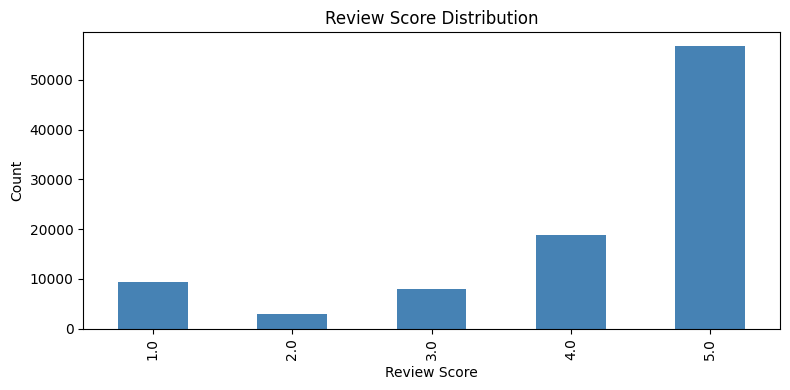

In [ ]:
print("Review Score Distribution:")
print(df['review_score'].value_counts().sort_index())

import matplotlib.pyplot as plt
df['review_score'].value_counts().sort_index().plot(
    kind='bar', color='steelblue', figsize=(8,4)
)
plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

###Final Validation

In [ ]:
print("FINAL DATASET")

print(f"Shape: {df.shape}")

print("\nRemaining Missing Values:")
print(df.isnull().sum()[df.isnull().sum() > 0])

print("\nDuplicate Rows:")
print(df.duplicated().sum())

print("\nDuplicate Order IDs:")
print(df['order_id'].duplicated().sum())

FINAL DATASET
Shape: (95809, 25)

Remaining Missing Values:
Series([], dtype: int64)

Duplicate Rows:
0

Duplicate Order IDs:
0


###Save Clean Dataset

In [ ]:
df.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Cleaned data/olist_cleaned.csv',
    index=False
)

print(" Saved olist_cleaned.csv")

 Saved olist_cleaned.csv


#PHASE 3 - EDA

## Customer Analysis

####Top States By Orders

In [ ]:
state_orders = (
    df['customer_state']
    .value_counts()
    .head(10)
)

print(state_orders)

customer_state
SP    40260
RJ    12209
MG    11282
RS     5324
PR     4900
SC     3519
BA     3229
DF     2070
ES     1969
GO     1946
Name: count, dtype: int64


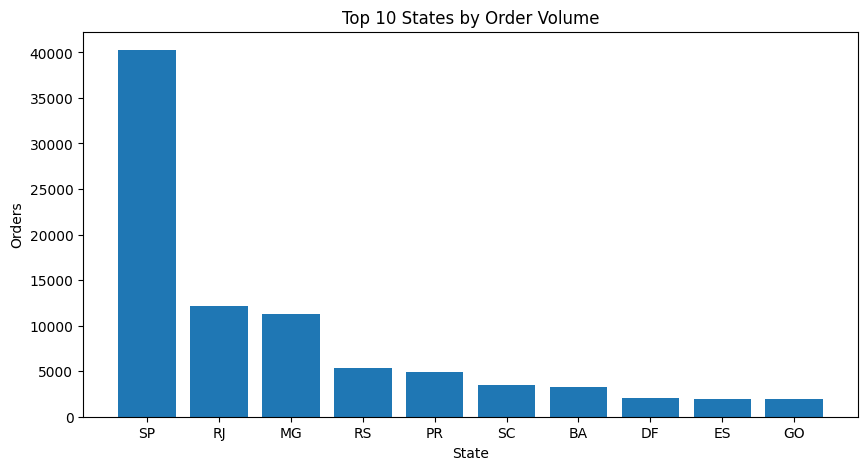

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    state_orders.index,
    state_orders.values
)

plt.title('Top 10 States by Order Volume')
plt.xlabel('State')
plt.ylabel('Orders')

plt.show()

###Top States By Revenue

In [ ]:
state_revenue = (
    df.groupby('customer_state')
      ['total_payment_value']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(state_revenue.round(2))

customer_state
SP    5736222.30
RJ    2026377.43
MG    1804229.70
RS     858100.79
PR     779570.14
BA     587085.36
SC     586512.00
DF     344789.44
GO     330127.14
PE     306980.68
Name: total_payment_value, dtype: float64


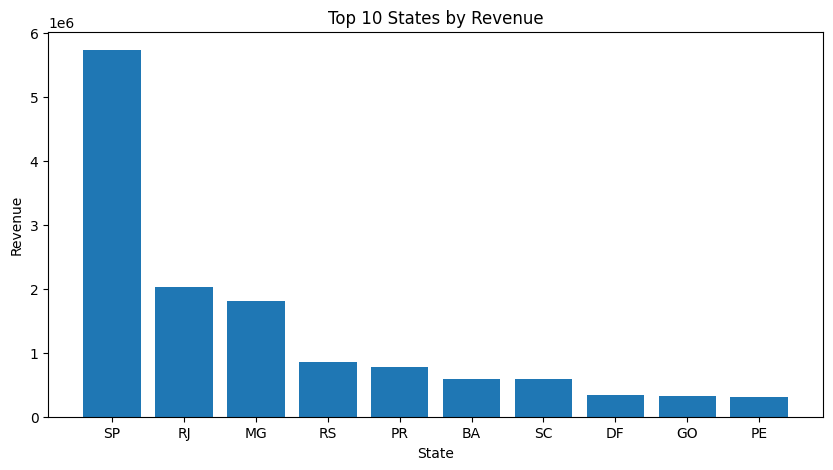

In [ ]:
plt.figure(figsize=(10,5))

plt.bar(
    state_revenue.index,
    state_revenue.values
)

plt.title('Top 10 States by Revenue')
plt.xlabel('State')
plt.ylabel('Revenue')

plt.show()

###Repeat Customer Analysis

In [ ]:
customer_orders = (
    df.groupby('customer_unique_id')
      ['order_id']
      .count()
)

one_time = (customer_orders == 1).sum()

repeat = (customer_orders > 1).sum()

print("One-time Customers:", one_time)
print("Repeat Customers:", repeat)

print(
    f"Repeat Rate: {round(repeat/len(customer_orders)*100,2)}%"
)

One-time Customers: 89970
Repeat Customers: 2763
Repeat Rate: 2.98%


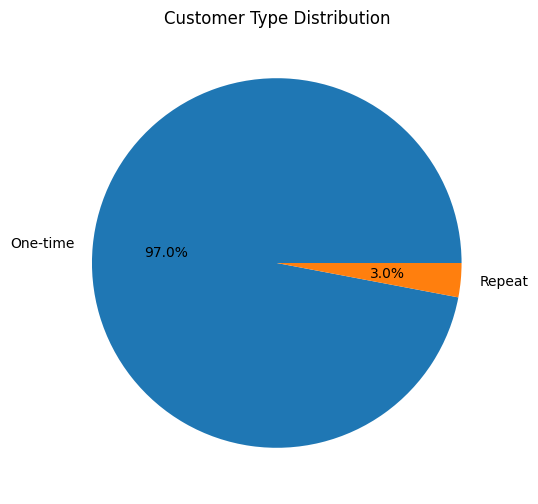

In [ ]:
plt.figure(figsize=(6,6))

plt.pie(
    [one_time, repeat],
    labels=['One-time','Repeat'],
    autopct='%1.1f%%'
)

plt.title('Customer Type Distribution')

plt.show()

##Product Analysis

###Top Categories by Order Volume

In [ ]:
top_cats = (
    df['product_category_name_english']
    .value_counts()
    .head(10)
)

print(top_cats)

product_category_name_english
bed_bath_table           9071
health_beauty            8562
sports_leisure           7444
computers_accessories    6469
furniture_decor          6163
housewares               5655
watches_gifts            5430
telephony                4051
auto                     3774
toys                     3748
Name: count, dtype: int64


/tmp/ipykernel_23336/545398485.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


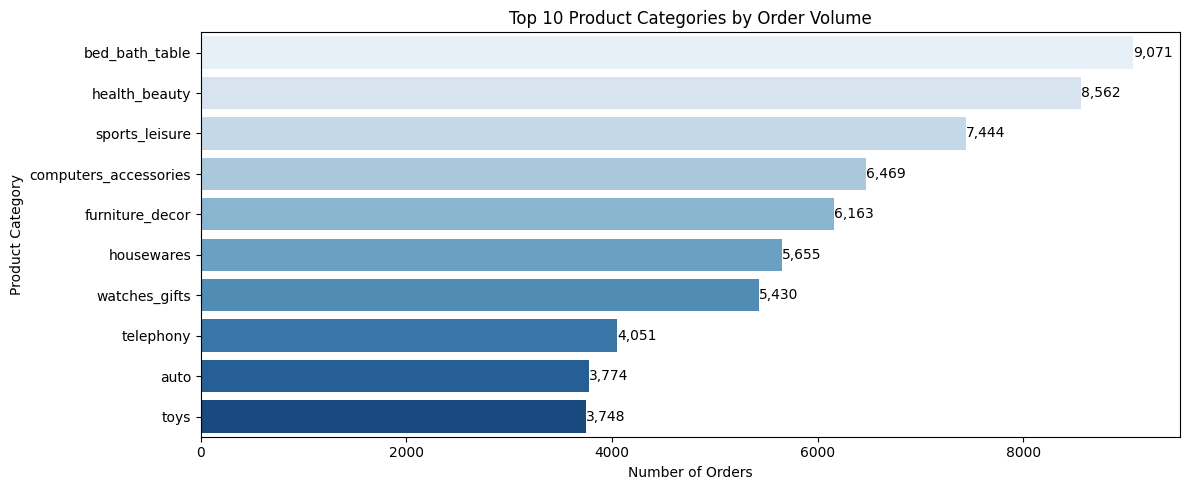

In [ ]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=top_cats.values,
    y=top_cats.index,
    palette='Blues'
)

plt.title('Top 10 Product Categories by Order Volume')
plt.xlabel('Number of Orders')
plt.ylabel('Product Category')

for i, value in enumerate(top_cats.values):
    plt.text(
        value,
        i,
        f'{value:,}',
        va='center'
    )

plt.tight_layout()
plt.show()

###Top Categories by Revenue

In [ ]:
cat_revenue = (
    df.groupby('product_category_name_english')
      ['total_payment_value']
      .sum()
      .sort_values(ascending=False)
      .head(10)
)

print(cat_revenue.round(2))

product_category_name_english
health_beauty            1401414.96
watches_gifts            1253999.82
bed_bath_table           1212163.53
sports_leisure           1112081.90
computers_accessories    1026111.47
furniture_decor           876073.88
housewares                756121.11
cool_stuff                684968.25
auto                      660932.95
garden_tools              563833.33
Name: total_payment_value, dtype: float64


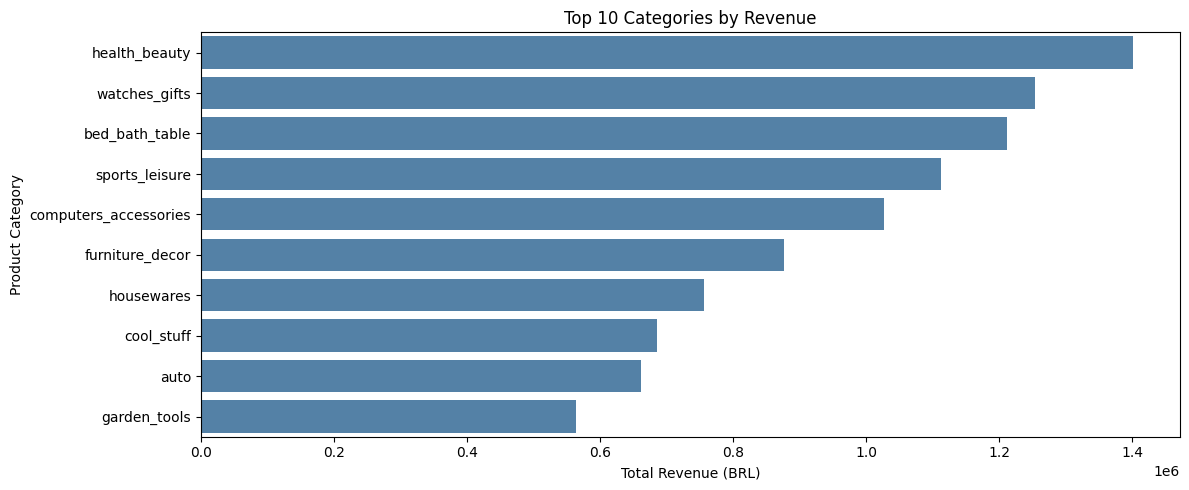

In [ ]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=cat_revenue.values,
    y=cat_revenue.index,
    color='steelblue'
)

plt.title('Top 10 Categories by Revenue')
plt.xlabel('Total Revenue (BRL)')
plt.ylabel('Product Category')

plt.tight_layout()
plt.show()

###Worst Rated Categories

In [ ]:
cat_satisfaction = (
    df.groupby('product_category_name_english')
      ['review_score']
      .agg(['mean','count'])
)

cat_satisfaction = (
    cat_satisfaction[
        cat_satisfaction['count'] >= 50
    ]
)

worst_cats = (
    cat_satisfaction
    .sort_values('mean')
    .head(10)
)

print(worst_cats)

                                   mean  count
product_category_name_english                 
office_furniture               3.650485   1236
fashion_male_clothing          3.819048    105
audio                          3.847507    341
home_confort                   3.907609    368
fixed_telephony                3.966507    209
fashion_underwear_beach        4.008621    116
bed_bath_table                 4.010252   9071
construction_tools_safety      4.013158    152
unknown                        4.022661   1368
home_construction              4.053879    464


/tmp/ipykernel_23336/1233812272.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


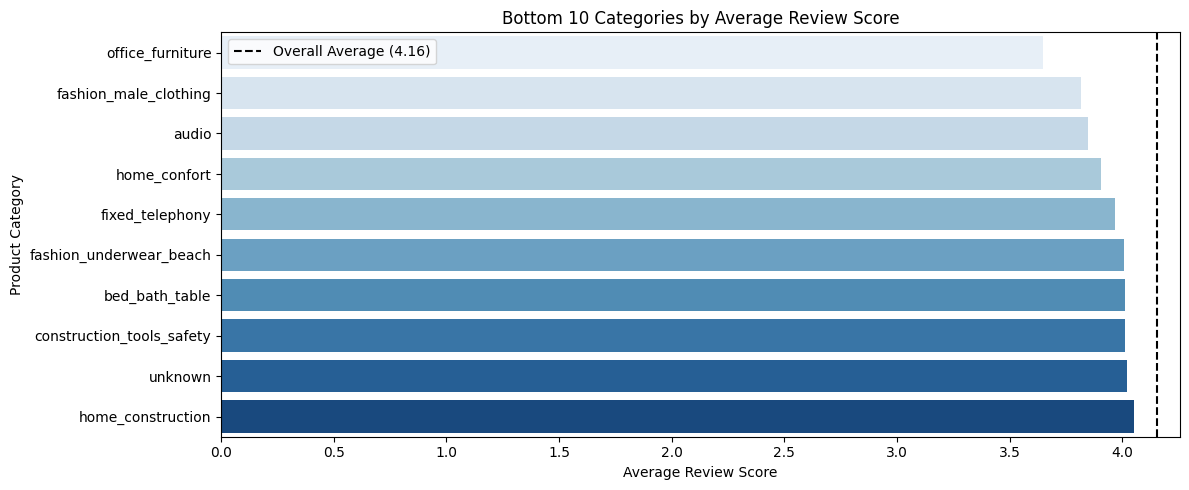

In [ ]:
plt.figure(figsize=(12,5))

ax = sns.barplot(
    x=worst_cats['mean'],
    y=worst_cats.index,
    palette='Blues'
)

plt.title('Bottom 10 Categories by Average Review Score')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')

overall_avg = df['review_score'].mean()

plt.axvline(
    x=overall_avg,
    color='black',
    linestyle='--',
    label=f'Overall Average ({overall_avg:.2f})'
)

plt.legend()

plt.tight_layout()
plt.show()

###Revenue Per Order

In [ ]:
category_metrics = (
    df.groupby('product_category_name_english')
      .agg(
          orders=('order_id','count'),
          revenue=('total_payment_value','sum')
      )
)

category_metrics['revenue_per_order'] = (
    category_metrics['revenue'] /
    category_metrics['orders']
)

category_metrics.sort_values(
    'revenue_per_order',
    ascending=False
).head(10)

,orders,revenue,revenue_per_order
product_category_name_english,,,
computers,173,217869.51,1259.361329
small_appliances_home_oven_and_coffee,72,49268.75,684.288194
home_appliances_2,225,117780.50,523.468889
agro_industry_and_commerce,177,76208.42,430.556045
musical_instruments,601,199334.54,331.671448
small_appliances,600,195881.86,326.469767
fixed_telephony,209,59257.95,283.530861
construction_tools_safety,152,41372.33,272.186382
office_furniture,1236,330519.16,267.410324


##SATISFACTION ANALYSIS

###Review Score Distribution

In [ ]:
score_counts = (
    df['review_score']
    .value_counts()
    .sort_index()
)

print(score_counts)

print(
    f"Average Review Score: {df['review_score'].mean():.3f}"
)

print(
    f"Dissatisfied Rate: {((df['review_score'] <= 2).mean()*100):.2f}%"
)

review_score
1.0     9351
2.0     2919
3.0     7915
4.0    18890
5.0    56734
Name: count, dtype: int64
Average Review Score: 4.156
Dissatisfied Rate: 12.81%


/tmp/ipykernel_23336/3930789146.py:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


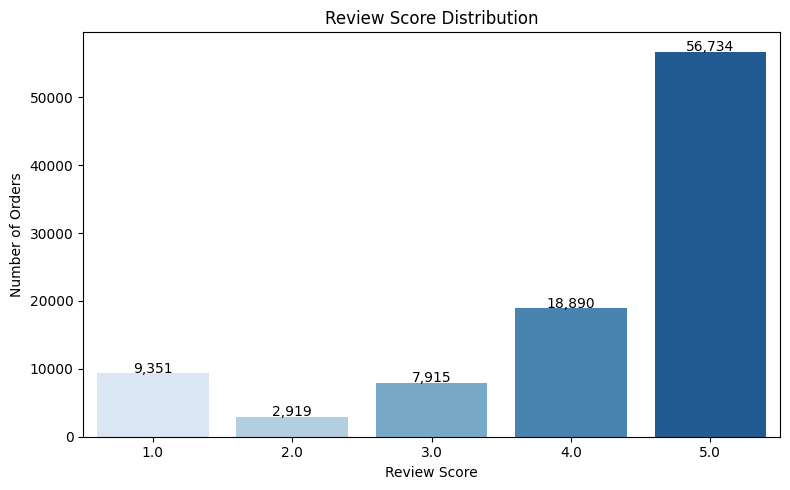

In [ ]:
plt.figure(figsize=(8,5))

score_counts = df['review_score'].value_counts().sort_index()

ax = sns.barplot(
    x=score_counts.index,
    y=score_counts.values,
    palette='Blues'
)

plt.title('Review Score Distribution')
plt.xlabel('Review Score')
plt.ylabel('Number of Orders')

for i, v in enumerate(score_counts.values):
    plt.text(
        i,
        v + 100,
        f'{v:,}',
        ha='center'
    )

plt.tight_layout()
plt.show()

###Satisfaction by state

In [ ]:
state_sat = df.groupby('customer_state')['review_score'].mean()
state_sat = state_sat.sort_values()

/tmp/ipykernel_23336/57302443.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


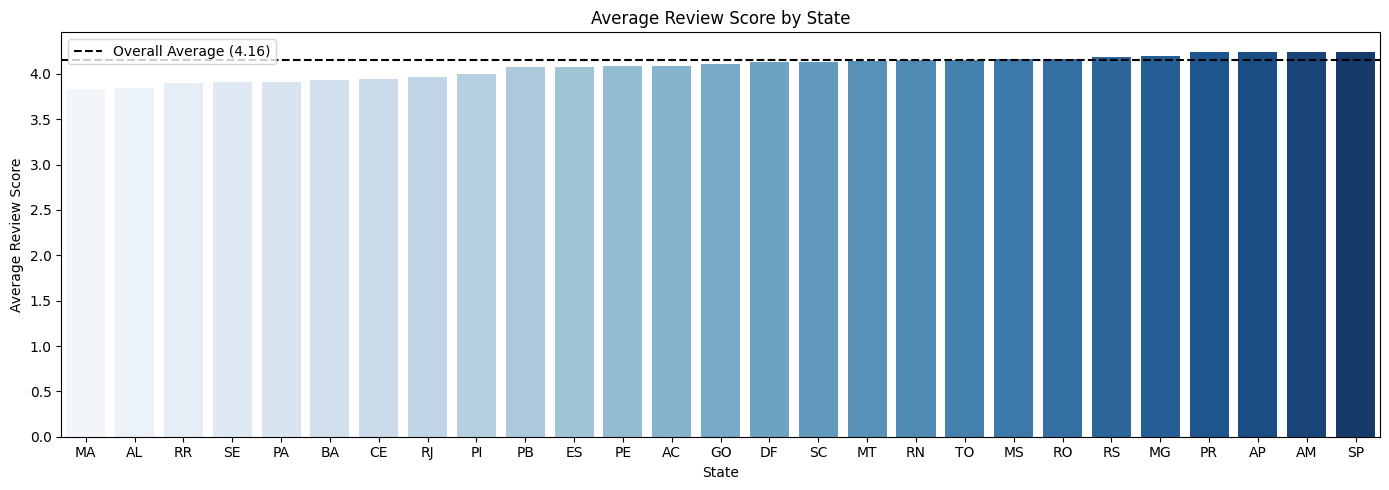

In [ ]:
plt.figure(figsize=(14,5))

ax = sns.barplot(
    x=state_sat.index,
    y=state_sat.values,
    palette='Blues'
)

plt.title('Average Review Score by State')
plt.xlabel('State')
plt.ylabel('Average Review Score')

overall_avg = df['review_score'].mean()

plt.axhline(
    y=overall_avg,
    color='black',
    linestyle='--',
    label=f'Overall Average ({overall_avg:.2f})'
)

plt.legend()

plt.tight_layout()
plt.show()

###Satisfaction by category

In [ ]:
top15_cats = (
    df['product_category_name_english']
    .value_counts()
    .head(15)
    .index
)

cat_sat = (
    df[df['product_category_name_english'].isin(top15_cats)]
    .groupby('product_category_name_english')['review_score']
    .mean()
    .sort_values()
)

/tmp/ipykernel_23336/3375139668.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


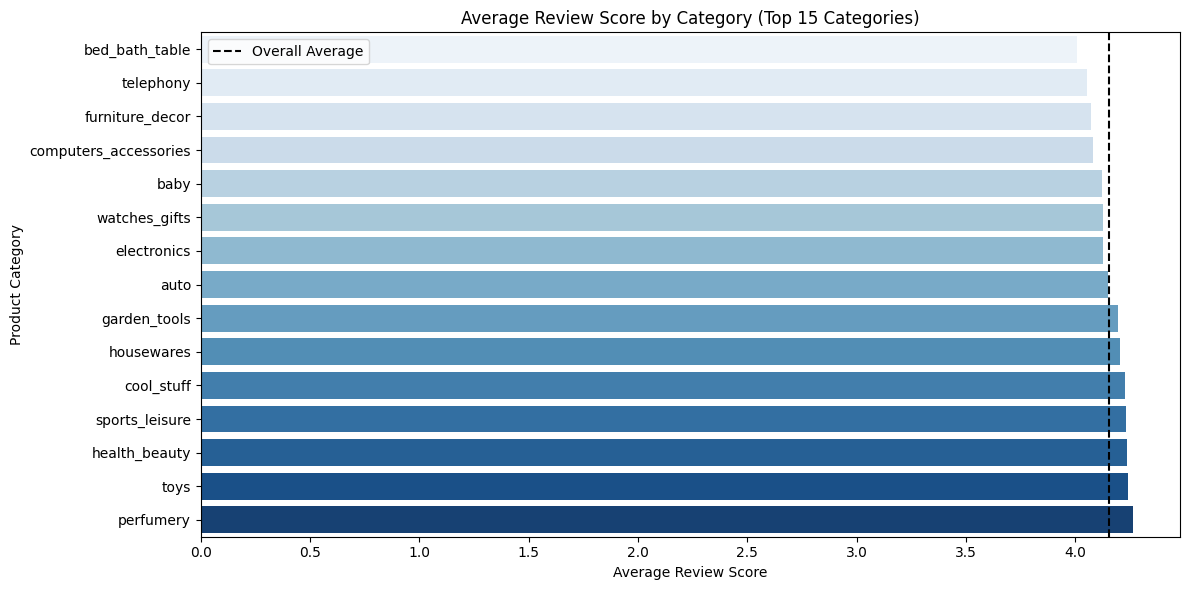

In [ ]:
plt.figure(figsize=(12, 6))

ax = sns.barplot(
    x=cat_sat.values,
    y=cat_sat.index,
    palette='Blues'
)

plt.title('Average Review Score by Category (Top 15 Categories)')
plt.xlabel('Average Review Score')
plt.ylabel('Product Category')

plt.axvline(
    x=df['review_score'].mean(),
    color='black',
    linestyle='--',
    label='Overall Average'
)

plt.legend()

plt.tight_layout()
plt.show()

##DELIVERY ANALYSIS

###Create Delivery Features

In [ ]:
df['delivery_delay_days'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days

df['is_late'] = (
    df['delivery_delay_days'] > 0
).astype(int)

print(df['is_late'].value_counts())

print("\nAverage Review Score by Delivery Status")

print(
    df.groupby('is_late')['review_score']
      .mean()
)

is_late
0    89429
1     6380
Name: count, dtype: int64

Average Review Score by Delivery Status
is_late
0    4.290320
1    2.270376
Name: review_score, dtype: float64


###Late vs On-time satisfaction

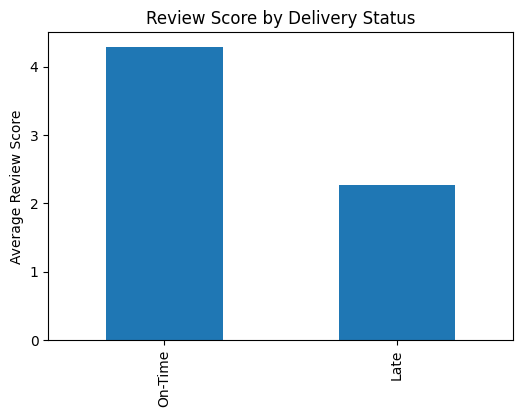

In [ ]:
delivery_sat = (
    df.groupby('is_late')['review_score']
      .mean()
)

delivery_sat.index = ['On-Time', 'Late']

delivery_sat.plot(
    kind='bar',
    figsize=(6,4)
)

plt.title('Review Score by Delivery Status')
plt.ylabel('Average Review Score')
plt.show()

###Delivery delay distribution

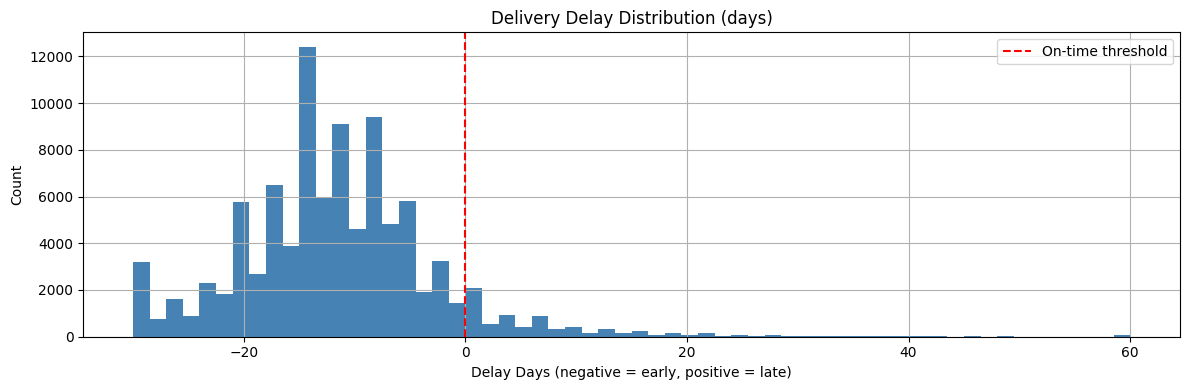

In [ ]:
plt.figure(figsize=(12, 4))
df['delivery_delay_days'].clip(-30, 60).hist(bins=60, color='steelblue')
plt.axvline(x=0, color='red', linestyle='--', label='On-time threshold')
plt.title('Delivery Delay Distribution (days)')
plt.xlabel('Delay Days (negative = early, positive = late)')
plt.ylabel('Count')
plt.legend()
plt.tight_layout()
plt.show()

###Fulfillment time vs review score

In [ ]:
df['total_fulfillment_days'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.days

In [ ]:
df['total_fulfillment_days']

,total_fulfillment_days
0,8
1,13
2,9
3,13
4,2
...,...
99436,8
99437,22
99438,24
99439,17


In [ ]:
bins = [0, 7, 14, 21, 30, 60, 200]
labels = ['0-7d', '8-14d', '15-21d', '22-30d', '31-60d', '60d+']

df['fulfillment_bucket'] = pd.cut(
    df['total_fulfillment_days'],
    bins=bins,
    labels=labels
)

bucket_sat = (
    df.groupby('fulfillment_bucket', observed=True)
      ['review_score']
      .mean()
)

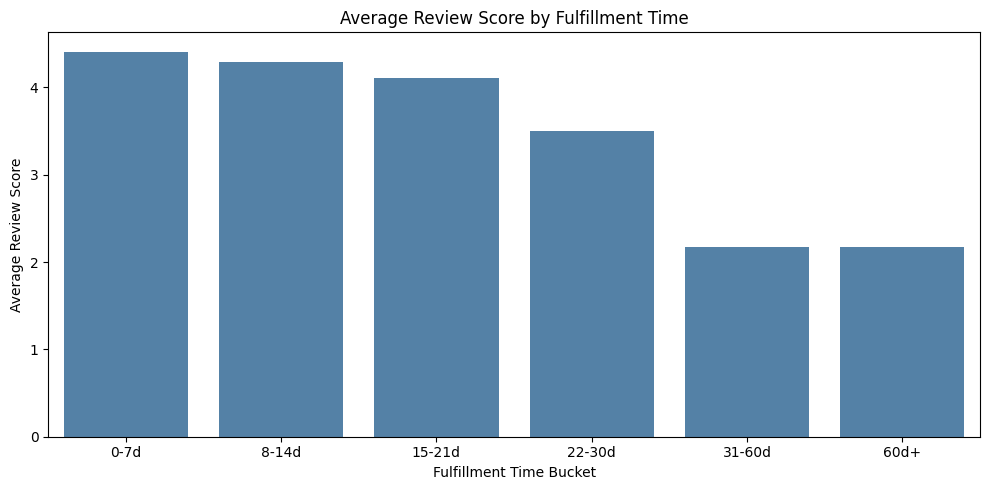

In [ ]:
plt.figure(figsize=(10, 5))

sns.barplot(
    x=bucket_sat.index,
    y=bucket_sat.values,
    color='steelblue'
)

plt.title('Average Review Score by Fulfillment Time')
plt.xlabel('Fulfillment Time Bucket')
plt.ylabel('Average Review Score')

plt.tight_layout()
plt.show()

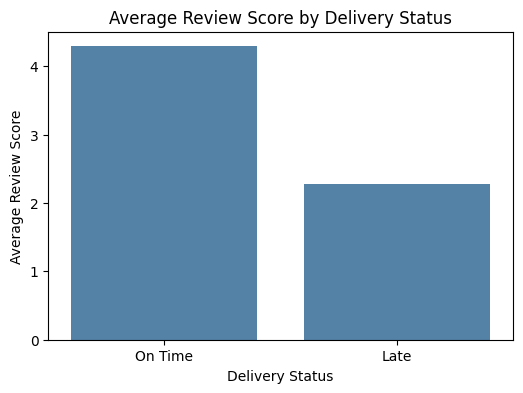

is_late
0    4.290320
1    2.270376
Name: review_score, dtype: float64


In [ ]:
delay_sat = df.groupby('is_late')['review_score'].mean()

plt.figure(figsize=(6,4))

sns.barplot(
    x=delay_sat.index,
    y=delay_sat.values,
    color='steelblue'
)

plt.xticks(
    [0,1],
    ['On Time', 'Late']
)

plt.ylabel('Average Review Score')
plt.xlabel('Delivery Status')

plt.title(
    'Average Review Score by Delivery Status'
)

plt.show()

print(delay_sat)

###Customer Dissatisfaction Rate by Delivery Delay

In [ ]:
df['dissatisfied'] = (
    df['review_score'] <= 2
).astype(int)

In [ ]:
df['delay_bucket'] = pd.cut(
    df['delivery_delay_days'],
    bins=[-float('inf'), -7, 0, 7, 14, float('inf')],
    labels=[
        'Very Early',
        'On Time',
        'Slightly Late',
        'Late',
        'Very Late'
    ]
)

# Calculate dissatisfaction percentage in each bucket
dissat_by_delay = (
    df.groupby(
        'delay_bucket',
        observed=True
    )['dissatisfied']
    .mean() * 100
).round(2)

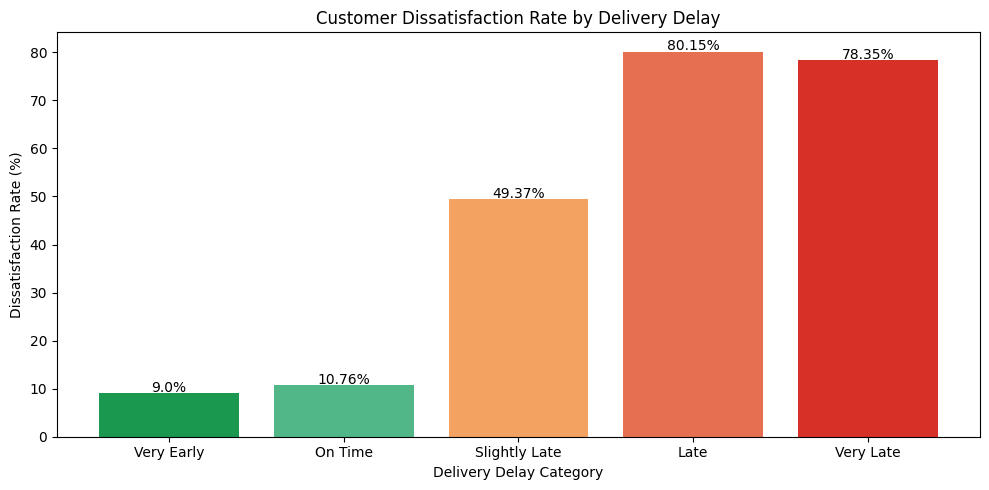

In [ ]:
plt.figure(figsize=(10,5))

colors = [
    '#1a9850',   # green
    '#52b788',   # light green
    '#f4a261',   # orange
    '#e76f51',   # red-orange
    '#d73027'    # red
]

plt.bar(
    dissat_by_delay.index,
    dissat_by_delay.values,
    color=colors
)

plt.title(
    'Customer Dissatisfaction Rate by Delivery Delay'
)

plt.xlabel('Delivery Delay Category')
plt.ylabel('Dissatisfaction Rate (%)')

for i, v in enumerate(dissat_by_delay.values):
    plt.text(
        i,
        v + 0.3,
        f'{v}%',
        ha='center'
    )

plt.tight_layout()
plt.show()

In [ ]:
#Customer dissatisfaction increases as delivery delay becomes more severe.

#Orders delivered on time exhibit lower dissatisfaction rates,
#while late deliveries show substantially higher dissatisfaction.

#This finding supports our hypothesis that delivery performance is a major driver of customer dissatisfaction

##PAYMENT ANALYSIS

###Payment type distribution

/tmp/ipykernel_23336/3524093983.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=payment_counts.index, y=payment_counts.values,


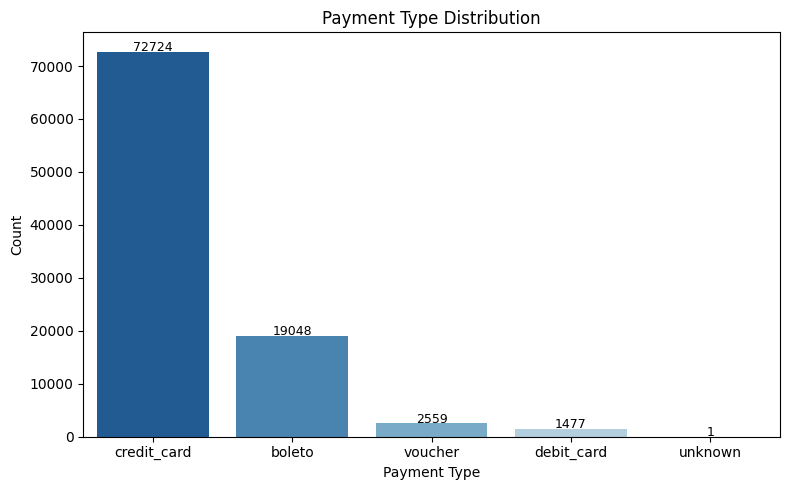

In [ ]:
plt.figure(figsize=(8, 5))
payment_counts = df['payment_type'].value_counts()
sns.barplot(x=payment_counts.index, y=payment_counts.values,
            palette='Blues_r')
plt.title('Payment Type Distribution')
plt.xlabel('Payment Type')
plt.ylabel('Count')
for i, v in enumerate(payment_counts.values):
    plt.text(i, v + 100, str(v), ha='center', fontsize=9)
plt.tight_layout()
plt.show()

###Payment type vs satisfaction

In [ ]:
pay_sat = (
    df.groupby('payment_type')
      ['review_score']
      .mean()
      .sort_values()
)

print(pay_sat.round(3))

payment_type
unknown        1.000
voucher        4.128
credit_card    4.155
boleto         4.156
debit_card     4.240
Name: review_score, dtype: float64


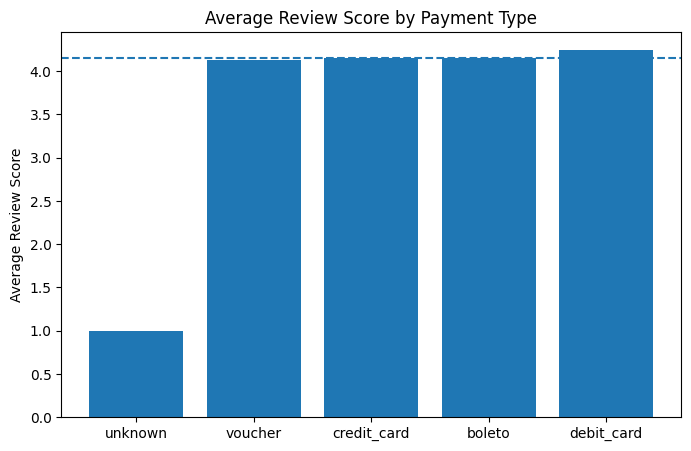

In [ ]:
plt.figure(figsize=(8,5))

plt.bar(
    pay_sat.index,
    pay_sat.values
)

plt.axhline(
    y=df['review_score'].mean(),
    linestyle='--'
)

plt.title('Average Review Score by Payment Type')
plt.ylabel('Average Review Score')

plt.show()

###Installments vs satisfaction

In [ ]:
installment_sat = (
    df.groupby('payment_installments')
      ['review_score']
      .agg(['mean','count'])
)

installment_sat = (
    installment_sat[
        installment_sat['count'] >= 100
    ]
)

print(installment_sat.head(15))

                          mean  count
payment_installments                 
1.0                   4.189071  46501
2.0                   4.173415  11954
3.0                   4.117507  10059
4.0                   4.119689   6826
5.0                   4.123388   5041
6.0                   4.142402   3764
7.0                   4.137128   1546
8.0                   4.094261   4095
9.0                   4.188525    610
10.0                  4.041667   5088
12.0                  4.047619    126


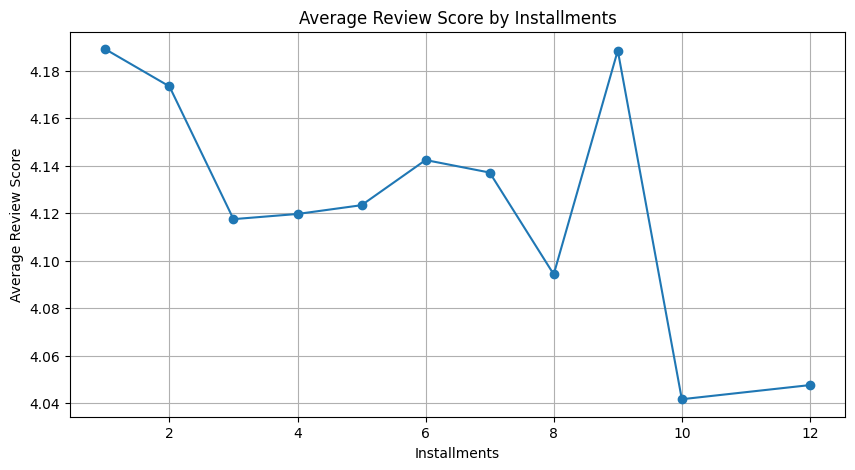

In [ ]:
plt.figure(figsize=(10,5))

plt.plot(
    installment_sat.index,
    installment_sat['mean'],
    marker='o'
)

plt.title('Average Review Score by Installments')
plt.xlabel('Installments')
plt.ylabel('Average Review Score')

plt.grid(True)

plt.show()

##TIME ANALYSIS

###Monthly order volume

In [ ]:
df['order_month_year'] = df['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = df.groupby('order_month_year')['order_id'].count()

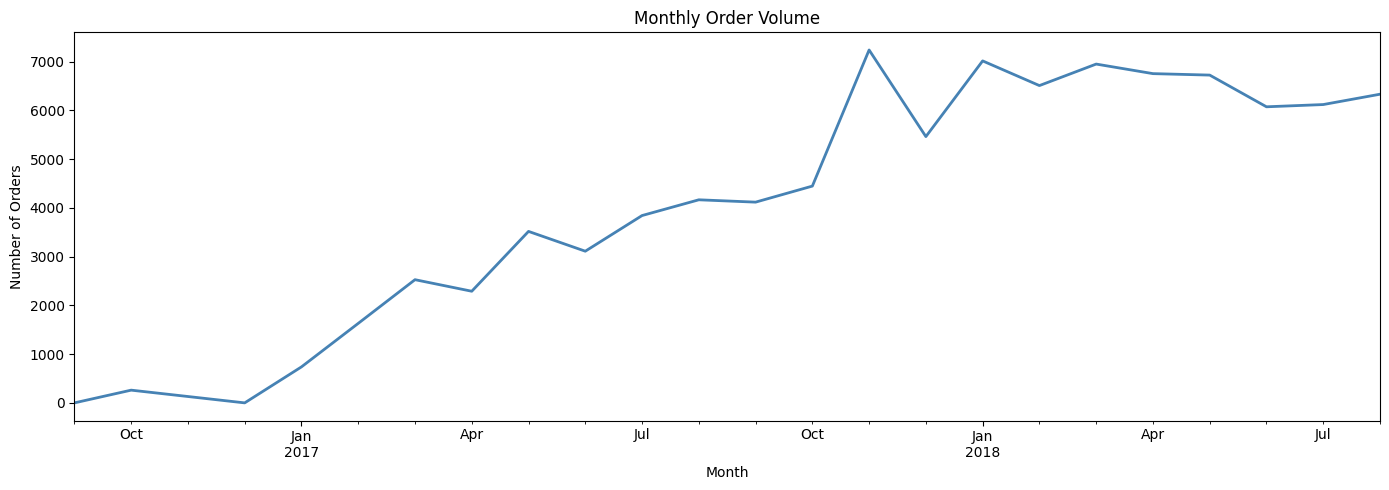

In [ ]:
plt.figure(figsize=(14, 5))
monthly_orders.plot(kind='line', color='steelblue', linewidth=2)
plt.title('Monthly Order Volume')
plt.xlabel('Month')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

###Orders by day of week

/tmp/ipykernel_23336/4190081656.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='Blues_r')


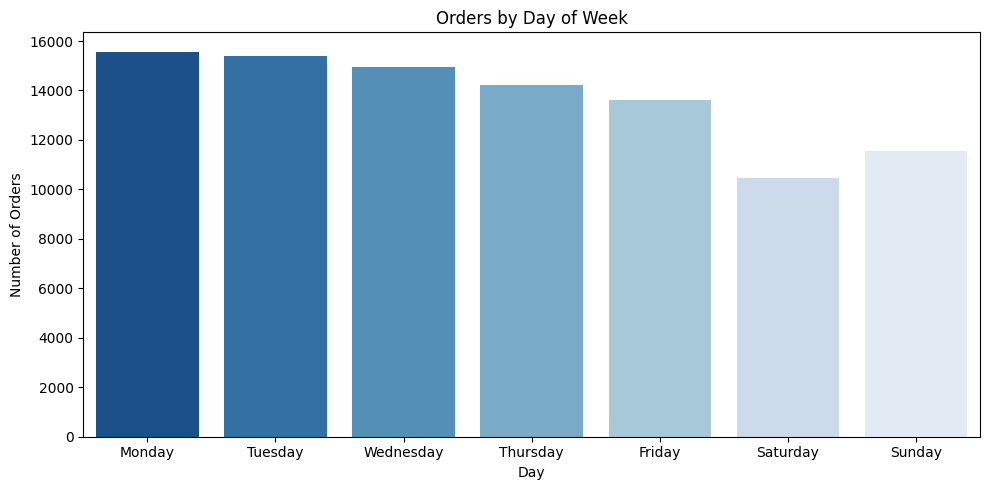

In [ ]:
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.day_name()
dow_order = ['Monday','Tuesday','Wednesday',
             'Thursday','Friday','Saturday','Sunday']
dow_counts = df['order_dayofweek'].value_counts().reindex(dow_order)

plt.figure(figsize=(10, 5))
sns.barplot(x=dow_counts.index, y=dow_counts.values, palette='Blues_r')
plt.title('Orders by Day of Week')
plt.xlabel('Day')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

##Correlation Analysis

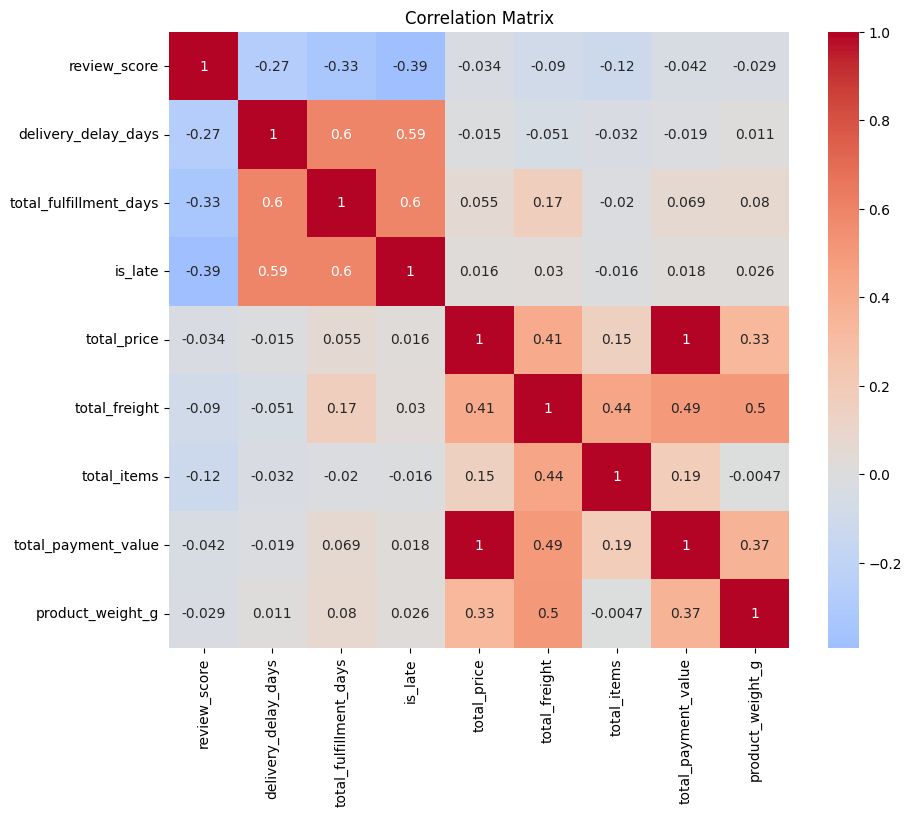

In [ ]:
corr_cols = [
    'review_score',
    'delivery_delay_days',
    'total_fulfillment_days',
    'is_late',
    'total_price',
    'total_freight',
    'total_items',
    'total_payment_value',
    'product_weight_g'
]

corr = df[corr_cols].corr()

plt.figure(figsize=(10,8))
sns.heatmap(
    corr,
    annot=True,
    cmap='coolwarm',
    center=0
)
plt.title('Correlation Matrix')
plt.show()

###Corealtion with review score

In [ ]:
review_corr = (
    corr['review_score']
    .drop('review_score')
    .sort_values()
)

print(review_corr)

is_late                  -0.391958
total_fulfillment_days   -0.333971
delivery_delay_days      -0.267364
total_items              -0.122876
total_freight            -0.089595
total_payment_value      -0.041790
total_price              -0.034440
product_weight_g         -0.028764
Name: review_score, dtype: float64


In [ ]:
#In Olist, review_score = one rating per order (not per product).
#It reflects the ENTIRE order experience:
#  - Product quality
#  - Delivery speed
# - Seller communication
#  - Packaging

#We cannot isolate exactly what caused dissatisfaction.
#However, we can measure WHICH FACTORS ARE MOST ASSOCIATED
#with low scores using correlation and SHAP.

### Key Business Insights

In [ ]:
print("KEY BUSINESS INSIGHTS SUMMARY")

print(f"""
CUSTOMER
  Top state by orders  : SP (40,260 orders)
  Top state by revenue : SP (BRL 5.7M)
  Repeat customer rate : 2.98% — overwhelmingly one-time buyers

PRODUCT
  Top category by volume  : bed_bath_table (9,071 orders)
  Top category by revenue : health_beauty (BRL 1.4M)
  Worst rated category    : office_furniture (avg 3.65)

SATISFACTION
  Overall avg score    : 4.156 / 5
  Dissatisfied rate    : 12.81% (score ≤ 2)
  Score 5 dominates    : 56,734 orders (59.2%)

DELIVERY
  On-time deliveries   : 89,429 (93.3%)
  Late deliveries      : 6,380 (6.7%)
  On-time avg score    : 4.29
  Late avg score       : 2.27
  Difference           : 2.02 points — strongest signal found

PAYMENT
  Most used method     : credit_card
  Highest satisfaction : debit_card (4.24)
  Lowest satisfaction  : voucher (4.13)

KEY FINDING FOR MODEL
  Late delivery is the strongest predictor of dissatisfaction.
  Avg score drops from 4.29 → 2.27 when delivery is late.
  This directly supports our early warning system framing.
""")

KEY BUSINESS INSIGHTS SUMMARY

CUSTOMER
  Top state by orders  : SP (40,260 orders)
  Top state by revenue : SP (BRL 5.7M)
  Repeat customer rate : 2.98% — overwhelmingly one-time buyers

PRODUCT
  Top category by volume  : bed_bath_table (9,071 orders)
  Top category by revenue : health_beauty (BRL 1.4M)
  Worst rated category    : office_furniture (avg 3.65)

SATISFACTION
  Overall avg score    : 4.156 / 5
  Dissatisfied rate    : 12.81% (score ≤ 2)
  Score 5 dominates    : 56,734 orders (59.2%)

DELIVERY
  On-time deliveries   : 89,429 (93.3%)
  Late deliveries      : 6,380 (6.7%)
  On-time avg score    : 4.29
  Late avg score       : 2.27
  Difference           : 2.02 points — strongest signal found

PAYMENT
  Most used method     : credit_card
  Highest satisfaction : debit_card (4.24)
  Lowest satisfaction  : voucher (4.13)

KEY FINDING FOR MODEL
  Late delivery is the strongest predictor of dissatisfaction.
  Avg score drops from 4.29 → 2.27 when delivery is late.
  This directl

# PHASE 4 - PREPROCESSING & FEATURE ENGINEERING

In [ ]:
print(df[['order_purchase_timestamp',
          'order_approved_at',
          'order_delivered_carrier_date',
          'order_delivered_customer_date',
          'order_estimated_delivery_date']].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


In [ ]:
date_cols = [
    'order_purchase_timestamp',
    'order_approved_at',
    'order_delivered_carrier_date',
    'order_delivered_customer_date',
    'order_estimated_delivery_date'
]

for col in date_cols:
    df[col] = pd.to_datetime(df[col])

print(df[date_cols].dtypes)

order_purchase_timestamp         datetime64[ns]
order_approved_at                datetime64[ns]
order_delivered_carrier_date     datetime64[ns]
order_delivered_customer_date    datetime64[ns]
order_estimated_delivery_date    datetime64[ns]
dtype: object


##Delay Features

In [ ]:
# Order confirmation delay (hours)

df['order_confirmation_delay_hrs'] = (
    df['order_approved_at']
    - df['order_purchase_timestamp']
).dt.total_seconds() / 3600


In [ ]:
# Dispatch delay

df['dispatch_delay_days'] = (
    df['order_delivered_carrier_date']
    - df['order_approved_at']
).dt.days

In [ ]:
# Delivery delay
df['delivery_delay_days'] = (
    df['order_delivered_customer_date']
    - df['order_estimated_delivery_date']
).dt.days

In [ ]:
# Fulfillment time

df['total_fulfillment_days'] = (
    df['order_delivered_customer_date']
    - df['order_purchase_timestamp']
).dt.days

In [ ]:
print("Delay feature summary:")
print(df[[
    'order_confirmation_delay_hrs',
    'dispatch_delay_days',
    'delivery_delay_days',
    'total_fulfillment_days'
]].describe().round(2))

Delay feature summary:
       order_confirmation_delay_hrs  dispatch_delay_days  delivery_delay_days  \
count                      95809.00             95809.00             95809.00   
mean                          10.28                 2.29               -11.91   
std                           20.54                 3.53                10.11   
min                            0.00              -172.00              -147.00   
25%                            0.22                 0.00               -17.00   
50%                            0.34                 1.00               -12.00   
75%                           14.52                 3.00                -7.00   
max                          741.44               125.00               188.00   

       total_fulfillment_days  
count                95809.00  
mean                    12.05  
std                      9.47  
min                      0.00  
25%                      6.00  
50%                     10.00  
75%                    

In [ ]:
# Remove impossible delay values
before = len(df)
df = df[df['order_confirmation_delay_hrs'] >= 0]
df = df[df['dispatch_delay_days'] >= 0]
df = df[df['total_fulfillment_days'] > 0]
print(f"Removed {before - len(df)} rows with impossible delay values")
print(f"Remaining: {len(df)} rows")

Removed 1354 rows with impossible delay values
Remaining: 94455 rows


##TIME FEATURES

In [ ]:
df['order_month']     = df['order_purchase_timestamp'].dt.month
df['order_dayofweek'] = df['order_purchase_timestamp'].dt.dayofweek
df['order_hour']      = df['order_purchase_timestamp'].dt.hour
df['order_year']      = df['order_purchase_timestamp'].dt.year

##Business Features

In [ ]:
# Freight ratio — freight as % of order value
# High freight ratio may signal dissatisfaction risk

df['freight_ratio'] = (
    df['total_freight']
    / df['total_price']
)


In [ ]:
# Is late flag

df['is_late'] = (df['delivery_delay_days'] > 0).astype(int)

In [ ]:
# Estimated delivery window (days seller promised)

df['estimated_delivery_window'] = (
    df['order_estimated_delivery_date'] -
    df['order_purchase_timestamp']
).dt.days

##SELLER & CATEGORY HISTORICAL FEATURES

In [ ]:
#Seller Average Rating

seller_avg = (
    df.groupby('seller_id')['review_score']
    .mean()
)

In [ ]:
#Seller Order Count

seller_count = (
    df.groupby('seller_id')['order_id']
    .count()
)

In [ ]:
#Category Average Rating

cat_avg = (
    df.groupby('product_category_name_english')
      ['review_score']
      .mean()
)

In [ ]:
#avg_item_price

df['avg_item_price'] = (
    df['total_price'] /
    df['total_items']
)

##Target Variable

In [ ]:
df['dissatisfied'] = (
    df['review_score'] <= 2
).astype(int)

print(df['dissatisfied'].value_counts())

dissatisfied
0    82316
1    12139
Name: count, dtype: int64


In [ ]:
#Review scores in Olist reflect the overall orderexperience

In [ ]:
print("Target variable distribution:")
print(df['dissatisfied'].value_counts())
print(f"\nDissatisfied rate: {round(df['dissatisfied'].mean()*100,2)}%")

Target variable distribution:
dissatisfied
0    82316
1    12139
Name: count, dtype: int64

Dissatisfied rate: 12.85%


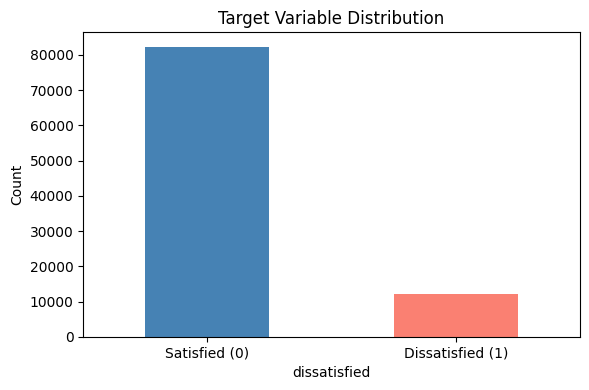

In [ ]:
df['dissatisfied'].value_counts().plot(
    kind='bar',
    color=['steelblue', 'salmon'],
    figsize=(6,4)
)

plt.xticks([0,1], ['Satisfied (0)', 'Dissatisfied (1)'], rotation=0)
plt.title('Target Variable Distribution')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

In [ ]:
#Class imbalance expected (~86% satisfied, ~14% dissatisfied)
#Will handle with SMOTE during model training.

##Encoding

In [ ]:
#cardinality

cat_cols = ['payment_type', 'customer_state',
            'product_category_name_english', 'seller_state']

for col in cat_cols:
    print(f"  {col:<40} {df[col].nunique()} unique values")

  payment_type                             5 unique values
  customer_state                           27 unique values
  product_category_name_english            72 unique values
  seller_state                             22 unique values


In [ ]:
for col in cat_cols:
    le = LabelEncoder()
    df[col + '_encoded'] = le.fit_transform(df[col])

##Feature Selection

In [ ]:
features = [
    'total_price',
    'total_freight',
    'total_items',
    'total_payment_value',
    'payment_installments',

    'freight_ratio',
    'avg_item_price',

    'estimated_delivery_window',

    'order_month',
    'order_dayofweek',
    'order_hour',

    'order_confirmation_delay_hrs',
    'dispatch_delay_days',
    'delivery_delay_days',
    'total_fulfillment_days',

    'is_late',

    'payment_type_encoded',
    'customer_state_encoded',
    'product_category_name_english_encoded',
    'seller_state_encoded'
]

target = 'dissatisfied'

In [ ]:
missing = [col for col in features if col not in df.columns]

print("Missing columns:", missing)

Missing columns: []


In [ ]:
X = df[features]
y = df[target]

print(X.shape)
print(y.shape)

print(y.value_counts())

(94455, 20)
(94455,)
dissatisfied
0    82316
1    12139
Name: count, dtype: int64


##TRAIN TEST SPLIT

In [ ]:
from sklearn.model_selection import train_test_split

X = df[features]
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train Shape:", X_train.shape)
print("Test Shape :", X_test.shape)

Train Shape: (75564, 20)
Test Shape : (18891, 20)


In [ ]:
print("\nTrain Distribution")
print(y_train.value_counts())

print("\nTrain Distribution (%)")
print((y_train.value_counts(normalize=True)*100).round(2))

print("\nTest Distribution")
print(y_test.value_counts())

print("\nTest Distribution (%)")
print((y_test.value_counts(normalize=True)*100).round(2))


Train Distribution
dissatisfied
0    65853
1     9711
Name: count, dtype: int64

Train Distribution (%)
dissatisfied
0    87.15
1    12.85
Name: proportion, dtype: float64

Test Distribution
dissatisfied
0    16463
1     2428
Name: count, dtype: int64

Test Distribution (%)
dissatisfied
0    87.15
1    12.85
Name: proportion, dtype: float64


##Scaling

In [ ]:
scaler = StandardScaler()

X_train_scaled = X_train.copy()
X_test_scaled = X_test.copy()

num_cols = [
    'total_price',
    'total_freight',
    'total_payment_value',
    'freight_ratio',
    'estimated_delivery_window',
    'order_confirmation_delay_hrs',
    'dispatch_delay_days',
    'delivery_delay_days',
    'total_fulfillment_days',
    'payment_installments',
    'total_items'
]

X_train_scaled[num_cols] = scaler.fit_transform(
    X_train[num_cols]
)

X_test_scaled[num_cols] = scaler.transform(
    X_test[num_cols]
)

##Imbalance Check

In [ ]:
print("Class Distribution")

print(y_train.value_counts())

print("\nPercentage Distribution")
print(
    (y_train.value_counts(normalize=True)*100)
    .round(2)
)

Class Distribution
dissatisfied
0    65853
1     9711
Name: count, dtype: int64

Percentage Distribution
dissatisfied
0    87.15
1    12.85
Name: proportion, dtype: float64


In [ ]:
#The target variable is imbalanced, with approximately 87% satisfied customers and 13% dissatisfied customers.
#To avoid data leakage, SMOTE will not be applied during preprocessing.
#SMOTE will be evaluated during the model training phase using only the training dataset.

In [ ]:
df.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Feature Engineered data/model_ready_dataset.csv',
    index=False
)

In [ ]:
X_train_scaled.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Processed Data/X_train_scaled.csv',
    index=False
)

X_test_scaled.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Processed Data/X_test_scaled.csv',
    index=False
)

y_train.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Processed Data/y_train.csv',
    index=False
)

y_test.to_csv(
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/data/Processed Data/y_test.csv',
    index=False
)

In [ ]:
import joblib

joblib.dump(
    scaler,
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/models/scaler.pkl'
)

print("Scaler saved")

Scaler saved


In [ ]:
joblib.dump(
    features,
    '/content/drive/MyDrive/Customer-Satisfaction-Retail-Analytics/models/features.pkl'
)

print("Features saved")

Features saved
